# Laboratório de dados reais — ERA5 + DETER

## Download, inspeção, tratamento e visualização didática

Este caderno faz a ponte entre os **dados ambientais reais** e o laboratório matemático de sistemas dinâmicos. O foco aqui não é estimar caos, mas construir séries confiáveis e compreender cada transformação antes de aplicar ferramentas não lineares.

Ao final, teremos:

- inventário e proveniência dos arquivos;
- visualização da estrutura espaço-temporal do ERA5;
- conversão para variáveis físicas interpretáveis;
- série horária em um ponto e agregação diária;
- controles básicos de qualidade e regularidade temporal;
- mapa, classes e evolução temporal dos alertas DETER;
- uma visão conjunta, estritamente exploratória, de clima e perturbação.

> **Importante:** ERA5 é uma reanálise (modelo + assimilação de observações), e DETER é um sistema de alertas. Nenhuma das duas fontes deve ser tratada como observação direta perfeita ou como prova causal isolada.

## Roteiro do caderno

1. Configurar o experimento e localizar os arquivos.
2. Exibir as requisições de download sem executá-las automaticamente.
3. Abrir e combinar os NetCDF do ERA5.
4. Derivar temperatura, déficit de pressão de vapor, vento, pressão e precipitação.
5. Extrair uma célula de grade, verificar qualidade e construir séries.
6. Ler, recortar e resumir os polígonos DETER.
7. Comparar as linhas do tempo e documentar limites de interpretação.

O caderno usa as rotinas versionadas em `src/amazon_chaos`, evitando duplicar regras críticas de processamento.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import numpy as np
import pandas as pd
import xarray as xr
try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = str
    display = print

# Permite executar a partir da raiz do projeto ou de uma subpasta.
HERE = Path.cwd().resolve()
ROOT = next(
    (candidate for candidate in [HERE, *HERE.parents] if (candidate / "pyproject.toml").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Não encontrei pyproject.toml. Abra o notebook dentro do projeto TCC.")

src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from amazon_chaos.config import load_config
from amazon_chaos.features.disturbance import summarize_deter
from amazon_chaos.io.era5 import build_request, merge_step_types
from amazon_chaos.preprocess.climate import (
    aggregate_daily,
    derive_climate_variables,
    extract_nearest_point,
    infer_coord_names,
)
from amazon_chaos.preprocess.quality import qc_table, time_regularity
from amazon_chaos.preprocess.spatial import add_area_km2, clip_bbox
from amazon_chaos.provenance import sha256_file

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.titlesize": 12, "axes.labelsize": 10})
pd.set_option("display.max_columns", 30)

print(f"Raiz do projeto: {ROOT}")
print(f"Python: {sys.version.split()[0]} | pandas: {pd.__version__} | xarray: {xr.__version__}")

Raiz do projeto: /home/thalles24006/TCC
Python: 3.11.7 | pandas: 3.0.5 | xarray: 2026.7.0


## 1. Configuração reprodutível

Datas, caixa geográfica, ponto piloto, variáveis e fontes vêm de `configs/pilot.yaml`. Assim, uma mudança de experimento fica registrada fora do código do notebook.

As chaves `EXECUTAR_DOWNLOAD` e `SALVAR_DERIVADOS` começam como `False` para impedir efeitos colaterais ao executar todas as células. Mude-as conscientemente quando necessário.

In [2]:
CONFIG_PATH = ROOT / "configs" / "pilot.yaml"
cfg = load_config(CONFIG_PATH)

EXECUTAR_DOWNLOAD = False
SALVAR_DERIVADOS = False

experiment_id = cfg["experiment_id"]
raw_base = ROOT / "data" / "raw" / experiment_id
era5_dir = raw_base / "era5"
deter_path = raw_base / "terrabrasilis" / "deter.geojson"
ibge_path = ROOT / "data" / "external" / "ibge_estados_minima.geojson"
processed_dir = ROOT / "data" / "processed"

config_table = pd.DataFrame(
    [
        ("Experimento", experiment_id),
        ("Período científico", f'{cfg["time"]["science_start"]} a {cfg["time"]["science_end"]}'),
        ("Período baixado", f'até {cfg["time"]["download_end"]} (1 dia extra para precipitação)'),
        ("Área [N, W, S, E]", cfg["spatial"]["area"]),
        ("Ponto piloto [lat, lon]", cfg["spatial"]["pilot_point"]),
        ("Download nesta execução?", EXECUTAR_DOWNLOAD),
        ("Salvar derivados?", SALVAR_DERIVADOS),
    ],
    columns=["item", "valor"],
)
display(config_table)

                       item                                           valor
0               Experimento                        pilot-era5-deter-2024-08
1        Período científico                         2024-08-01 a 2024-08-07
2           Período baixado  até 2024-08-08 (1 dia extra para precipitação)
3         Área [N, W, S, E]                      [-1.0, -56.0, -4.0, -53.5]
4   Ponto piloto [lat, lon]                                  [-2.5, -54.75]
5  Download nesta execução?                                           False
6         Salvar derivados?                                           False


## 2. Aquisição explícita dos dados

O ERA5 é obtido pelo **Climate Data Store (CDS)**. Variáveis instantâneas e acumuladas são solicitadas separadamente porque podem ter semânticas temporais distintas. O DETER é obtido pelo serviço WFS do TerraBrasilis, após descobrir a camada e o campo de data publicados pelo servidor.

A célula seguinte apenas mostra os pedidos ERA5. Ela é útil para conferir área, datas, horários e variáveis **antes** de transferir dados. Credenciais nunca são exibidas nem armazenadas no notebook.

In [3]:
start = str(cfg["time"]["science_start"])
download_end = str(cfg["time"]["download_end"])
era_cfg = cfg["era5"]

request_instant = build_request(cfg, era_cfg["variables"]["instant"], start, download_end)
request_accum = build_request(cfg, era_cfg["variables"]["accum"], start, download_end)

request_preview = pd.DataFrame(
    {
        "instantâneas": pd.Series(request_instant),
        "acumuladas": pd.Series(request_accum),
    }
)
display(request_preview)
print("Dataset CDS:", era_cfg["dataset"])
print("Por que há um dia extra? Para fechar corretamente a soma da precipitação do último dia científico.")

                                                      instantâneas  \
product_type                                          [reanalysis]   
variable         _temperature, 2m_dewpoint_temperature, surf...   
year                                                        [2024]   
month                                                         [08]   
day                               [01, 02, 03, 04, 05, 06, 07, 08]   
time             [00:00, 01:00, 02:00, 03:00, 04:00, 05:00, 06:...   
data_format                                                 netcdf   
download_format                                         unarchived   
area                                    [-1.0, -56.0, -4.0, -53.5]   

                                                        acumuladas  
product_type                                          [reanalysis]  
variable                                     [total_precipitation]  
year                                                        [2024]  
month                     

In [4]:
if EXECUTAR_DOWNLOAD:
    from amazon_chaos.io.era5 import download_pilot
    from amazon_chaos.io.terrabrasilis import download_deter_pilot

    cdsapirc = Path.home() / ".cdsapirc"
    if not cdsapirc.exists():
        raise FileNotFoundError(
            "~/.cdsapirc não encontrado. Configure sua credencial do CDS e aceite os termos do ERA5."
        )

    era5_dir.mkdir(parents=True, exist_ok=True)
    deter_path.parent.mkdir(parents=True, exist_ok=True)
    instant_downloaded, accum_downloaded = download_pilot(cfg, era5_dir)
    deter_downloaded = download_deter_pilot(cfg, deter_path)
    print("ERA5 instantâneo:", instant_downloaded)
    print("ERA5 acumulado:", accum_downloaded)
    print("DETER:", deter_downloaded)
else:
    print("Download desativado. Serão usados apenas arquivos locais já existentes.")
    print("Para baixar deliberadamente, defina EXECUTAR_DOWNLOAD = True e execute esta célula.")

Download desativado. Serão usados apenas arquivos locais já existentes.
Para baixar deliberadamente, defina EXECUTAR_DOWNLOAD = True e execute esta célula.


### Inventário local e integridade

O tamanho ajuda a detectar arquivos vazios ou inesperados. O SHA-256 identifica exatamente os bytes usados na análise e facilita a auditoria posterior.

In [5]:
instant_files = sorted(era5_dir.glob("era5_instant*.nc")) + sorted(
    (era5_dir / "era5_instant_extracted").glob("**/*.nc")
)
accum_files = sorted(era5_dir.glob("era5_accum*.nc")) + sorted(
    (era5_dir / "era5_accum_extracted").glob("**/*.nc")
)
expected_files = [*instant_files, *accum_files, deter_path, ibge_path]


inventory = []
for path in expected_files:
    path = Path(path)
    inventory.append(
        {
            "arquivo": str(path.relative_to(ROOT)) if path.exists() else str(path),
            "existe": path.exists(),
            "tamanho_MiB": path.stat().st_size / 2**20 if path.exists() else np.nan,
            "sha256_12": sha256_file(path)[:12] if path.exists() else None,
        }
    )
inventory = pd.DataFrame(inventory)
display(inventory.round({"tamanho_MiB": 3}))

if not instant_files or not accum_files or not deter_path.exists() or not ibge_path.exists():
    raise FileNotFoundError(
        "Faltam dados locais. Ative o download ou rode: uv run amazon-chaos pilot --config configs/pilot.yaml"
    )

                                             arquivo  existe  tamanho_MiB  \
0  data/raw/pilot-era5-deter-2024-08/era5/era5_in...    True        0.322   
1  data/raw/pilot-era5-deter-2024-08/era5/era5_ac...    True        0.036   
2  data/raw/pilot-era5-deter-2024-08/terrabrasili...    True        2.471   
3          data/external/ibge_estados_minima.geojson    True        0.094   

      sha256_12  
0  79313b965564  
1  00dce6a9f757  
2  b0554083c18c  
3  07c671aa87aa  


## 3. ERA5: do cubo espaço-temporal às variáveis físicas

Sim: cada variável do ERA5 pode ser lida como um array rotulado

$$
V[t,\,y,\,x] = V[\mathrm{tempo},\,\mathrm{latitude},\,\mathrm{longitude}].
$$

Neste piloto, cada variável possui forma **(192, 13, 11)**:

- **192:** oito dias × 24 horários; o oitavo dia é auxiliar para fechar a precipitação;
- **13:** posições de latitude, de −1° a −4°, espaçadas em 0,25°;
- **11:** posições de longitude, de −56° a −53,5°, espaçadas em 0,25°.

A grade contém $13\times11=143$ células. Portanto, **cada quadradinho possui 192 valores de cada variável**: 192 temperaturas, 192 VPDs, 192 ventos etc. Para precipitação, cada número é o acumulado da hora que termina naquele timestamp.

Tecnicamente, um xarray.Dataset é uma coleção de arrays rotulados, não um único cubo com todas as variáveis misturadas. A variável t2m tem seu array (192, 13, 11), a variável tp tem outro, e assim por diante; todos compartilham as mesmas coordenadas. Se empilhássemos seis variáveis manualmente, poderíamos formar um array (6, 192, 13, 11), mas o xarray preserva cada variável e seus metadados separadamente.

In [6]:
ds_raw = merge_step_types(instant_files, accum_files).sortby("valid_time")
time_name, lat_name, lon_name = infer_coord_names(ds_raw)

print(ds_raw)
print()
print("Variáveis:", list(ds_raw.data_vars))
print("Intervalo temporal:", pd.Timestamp(ds_raw[time_name].min().item()), "a", pd.Timestamp(ds_raw[time_name].max().item()))
print("Grade:", ds_raw.sizes[lat_name], "latitudes ×", ds_raw.sizes[lon_name], "longitudes")

<xarray.Dataset> Size: 664kB
Dimensions:     (valid_time: 192, latitude: 13, longitude: 11)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2024-08-01 ... 2024-08-08T23:...
    expver      (valid_time) <U4 3kB '0001' '0001' '0001' ... '0001' '0001'
  * latitude    (latitude) float64 104B -1.0 -1.25 -1.5 ... -3.5 -3.75 -4.0
  * longitude   (longitude) float64 88B -56.0 -55.75 -55.5 ... -53.75 -53.5
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 110kB ...
    d2m         (valid_time, latitude, longitude) float32 110kB ...
    sp          (valid_time, latitude, longitude) float32 110kB ...
    u10         (valid_time, latitude, longitude) float32 110kB ...
    v10         (valid_time, latitude, longitude) float32 110kB ...
    tp          (valid_time, latitude, longitude) float32 110kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_

### Três maneiras de cortar o cubo

Para uma variável $V[t,y,x]$:

- V.isel(tempo=0) fixa o tempo e produz **um mapa 13 × 11**;
- V.isel(latitude=6, longitude=5) fixa o espaço e produz **uma série com 192 horários**;
- V.isel(tempo=0, latitude=6, longitude=5) fixa tudo e produz **um único número**.

Cada posição do array está ligada às coordenadas mostradas pelo xarray; por isso sabemos a data, a latitude, a longitude e a unidade física de cada valor.

         seleção       notação forma resultante  número de valores
0  cubo completo  t2m[:, :, :]    (192, 13, 11)              27456
1        um mapa  t2m[0, :, :]         (13, 11)                143
2      uma série  t2m[:, 6, 5]           (192,)                192
3       um valor  t2m[0, 6, 5]               ()                  1
Um único valor: 29.19 °C em 01/08/2024 00:00 UTC, latitude -2.50, longitude -54.75.


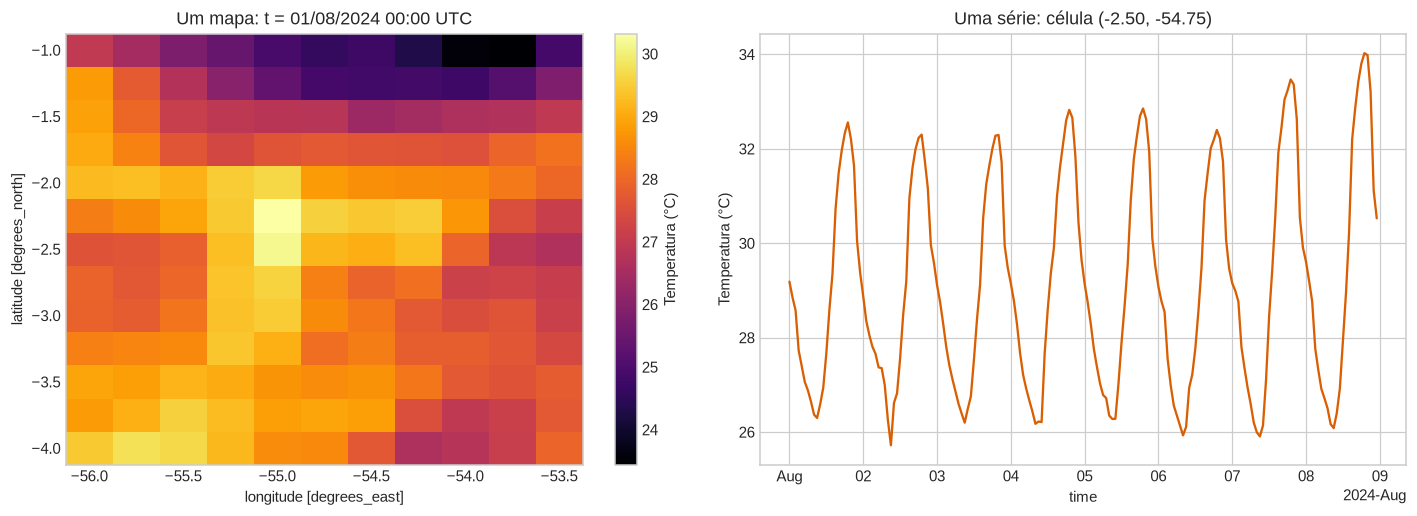

In [7]:
temperature_cube = ds_raw["t2m"]
middle_lat = ds_raw.sizes[lat_name] // 2
middle_lon = ds_raw.sizes[lon_name] // 2

cube_table = pd.DataFrame(
    [
        ("cubo completo", "t2m[:, :, :]", temperature_cube.shape, temperature_cube.size),
        ("um mapa", "t2m[0, :, :]", temperature_cube.isel({time_name: 0}).shape,
         temperature_cube.isel({time_name: 0}).size),
        ("uma série", f"t2m[:, {middle_lat}, {middle_lon}]",
         temperature_cube.isel({lat_name: middle_lat, lon_name: middle_lon}).shape,
         temperature_cube.isel({lat_name: middle_lat, lon_name: middle_lon}).size),
        ("um valor", f"t2m[0, {middle_lat}, {middle_lon}]", (), 1),
    ],
    columns=["seleção", "notação", "forma resultante", "número de valores"],
)
display(cube_table)

scalar_kelvin = float(temperature_cube.isel(
    {time_name: 0, lat_name: middle_lat, lon_name: middle_lon}
))
scalar_time = pd.Timestamp(temperature_cube[time_name].isel({time_name: 0}).item())
scalar_lat = float(temperature_cube[lat_name].isel({lat_name: middle_lat}))
scalar_lon = float(temperature_cube[lon_name].isel({lon_name: middle_lon}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
(temperature_cube.isel({time_name: 0}) - 273.15).plot(
    ax=axes[0], cmap="inferno", cbar_kwargs={"label": "Temperatura (°C)"}
)
axes[0].set_title(f"Um mapa: t = {scalar_time:%d/%m/%Y %H:%M} UTC")
(temperature_cube.isel({lat_name: middle_lat, lon_name: middle_lon}) - 273.15).plot(
    ax=axes[1], color="#d95f02"
)
axes[1].set_title(f"Uma série: célula ({scalar_lat:.2f}, {scalar_lon:.2f})")
axes[1].set_ylabel("Temperatura (°C)")
fig.tight_layout()
plt.show()

print(
    f"Um único valor: {scalar_kelvin - 273.15:.2f} °C em "
    f"{scalar_time:%d/%m/%Y %H:%M} UTC, latitude {scalar_lat:.2f}, longitude {scalar_lon:.2f}."
)

In [8]:
raw_overview = []
for name, arr in ds_raw.data_vars.items():
    raw_overview.append(
        {
            "variável": name,
            "dimensões": " × ".join(arr.dims),
            "forma": str(arr.shape),
            "unidade_original": arr.attrs.get("units", "não informada"),
            "mínimo": float(arr.min(skipna=True)),
            "máximo": float(arr.max(skipna=True)),
        }
    )
display(pd.DataFrame(raw_overview).round({"mínimo": 4, "máximo": 4}))

  variável                          dimensões          forma unidade_original  \
0      t2m  valid_time × latitude × longitude  (192, 13, 11)                K   
1      d2m  valid_time × latitude × longitude  (192, 13, 11)                K   
2       sp  valid_time × latitude × longitude  (192, 13, 11)               Pa   
3      u10  valid_time × latitude × longitude  (192, 13, 11)          m s**-1   
4      v10  valid_time × latitude × longitude  (192, 13, 11)          m s**-1   
5       tp  valid_time × latitude × longitude  (192, 13, 11)                m   

       mínimo       máximo  
0    291.4995     309.8289  
1    288.0798     299.3250  
2  95633.5000  101384.8125  
3     -5.1985       0.7151  
4     -3.5468       2.9438  
5      0.0000       0.0019  


### Transformações realizadas

| Saída | Cálculo | Interpretação |
|---|---|---|
| `t2m_c` | $T(^\circ C)=T(K)-273{,}15$ | temperatura a 2 m |
| `d2m_c` | $T_d(^\circ C)=T_d(K)-273{,}15$ | temperatura do ponto de orvalho |
| `vpd_kpa` | $VPD=e_s(T)-e_s(T_d)$ | demanda evaporativa aproximada do ar |
| `surface_pressure_hpa` | $p(hPa)=p(Pa)/100$ | pressão à superfície |
| `wind_speed_10m` | $\sqrt{u_{10}^2+v_{10}^2}$ | módulo do vento a 10 m |
| `precip_mm_hour_ending` | $tp(m)\times1000$ | acumulado da hora que termina no timestamp |

Para o VPD usamos $e_s(T)=0{,}6108\exp\left(17{,}27T/(T+237{,}3)\right)$, com temperatura em °C e pressão em kPa. Valores negativos residuais são truncados em zero.

In [9]:
climate = derive_climate_variables(ds_raw)

descriptions = {
    "t2m_c": "temperatura do ar a 2 m",
    "d2m_c": "temperatura do ponto de orvalho a 2 m",
    "vpd_kpa": "déficit de pressão de vapor",
    "surface_pressure_hpa": "pressão à superfície",
    "wind_speed_10m": "velocidade do vento a 10 m",
    "precip_mm_hour_ending": "precipitação da hora terminando no timestamp",
}
derived_overview = pd.DataFrame(
    [
        {
            "variável": name,
            "significado": descriptions[name],
            "unidade": arr.attrs.get("units", ""),
            "mínimo": float(arr.min(skipna=True)),
            "média": float(arr.mean(skipna=True)),
            "máximo": float(arr.max(skipna=True)),
        }
        for name, arr in climate.data_vars.items()
    ]
)
display(derived_overview.round({"mínimo": 3, "média": 3, "máximo": 3}))

                variável                                   significado  \
0                  t2m_c                       temperatura do ar a 2 m   
1                  d2m_c         temperatura do ponto de orvalho a 2 m   
2                vpd_kpa                   déficit de pressão de vapor   
3   surface_pressure_hpa                          pressão à superfície   
4  precip_mm_hour_ending  precipitação da hora terminando no timestamp   
5         wind_speed_10m                    velocidade do vento a 10 m   

  unidade   mínimo    média    máximo  
0    degC   18.350   28.112    36.679  
1    degC   14.930   20.963    26.175  
2     kPa    0.012    1.396     4.124  
3     hPa  956.335  997.216  1013.848  
4      mm    0.000    0.003     1.872  
5   m s-1    0.106    2.563     5.492  


### A grade espacial

O mapa abaixo é uma média do período baixado em cada célula. Cada quadrado colorido representa uma célula da reanálise e resume seus 192 horários. A borda vermelha coincide com os limites da própria área solicitada.

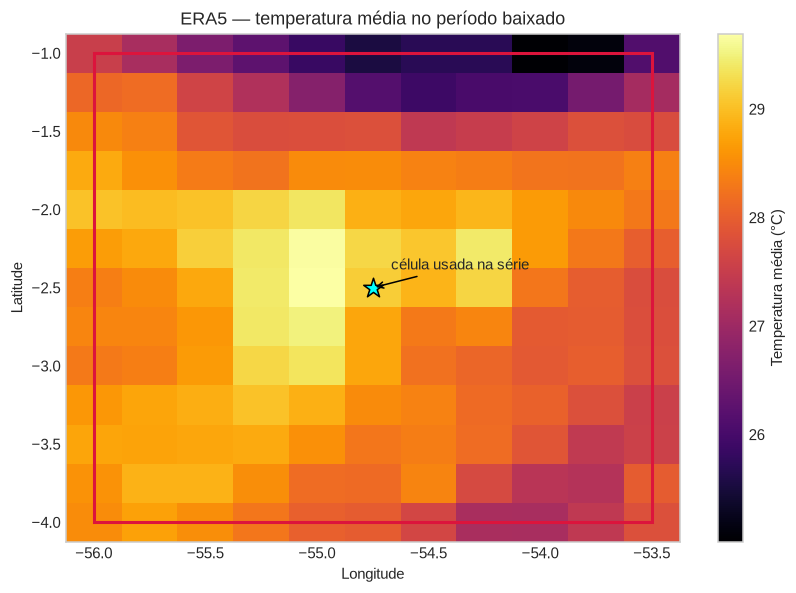

In [10]:
area = cfg["spatial"]["area"]
north, west, south, east = area
mean_temperature = climate["t2m_c"].mean(time_name)

fig, ax = plt.subplots(figsize=(9, 6))
mean_temperature.plot(ax=ax, cmap="inferno", cbar_kwargs={"label": "Temperatura média (°C)"})
ax.add_patch(Rectangle((west, south), east - west, north - south, fill=False, ec="crimson", lw=2))
ax.scatter(cfg["spatial"]["pilot_point"][1], cfg["spatial"]["pilot_point"][0], marker="*", s=180,
           color="cyan", edgecolor="black", label="ponto solicitado")
ax.set(title="ERA5 — temperatura média no período baixado", xlabel="Longitude", ylabel="Latitude")
ax.annotate(
    "célula usada na série",
    xy=(cfg["spatial"]["pilot_point"][1], cfg["spatial"]["pilot_point"][0]),
    xytext=(12, 12),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "black"},
)
plt.show()

### Onde fica essa caixa no território brasileiro?

A primeira figura mostrava somente a grade solicitada, por isso não havia costa, estados ou cidades. A malha abaixo vem da API de Malhas Geográficas do IBGE e fornece contexto territorial.

Em verde aparecem os nove estados que integram total ou parcialmente a **Amazônia Legal**. Isso é uma contextualização político-administrativa simplificada: não é o limite do bioma Amazônia, e apenas parte do Maranhão pertence à Amazônia Legal. A caixa vermelha é exatamente o domínio ERA5 deste piloto, localizado no Pará.

Fonte cartográfica: [API de Malhas Geográficas do IBGE](https://servicodados.ibge.gov.br/api/docs/malhas?versao=3), consulta do Brasil subdividido por UFs em qualidade mínima. Arquivo local registrado no inventário para execução sem internet.

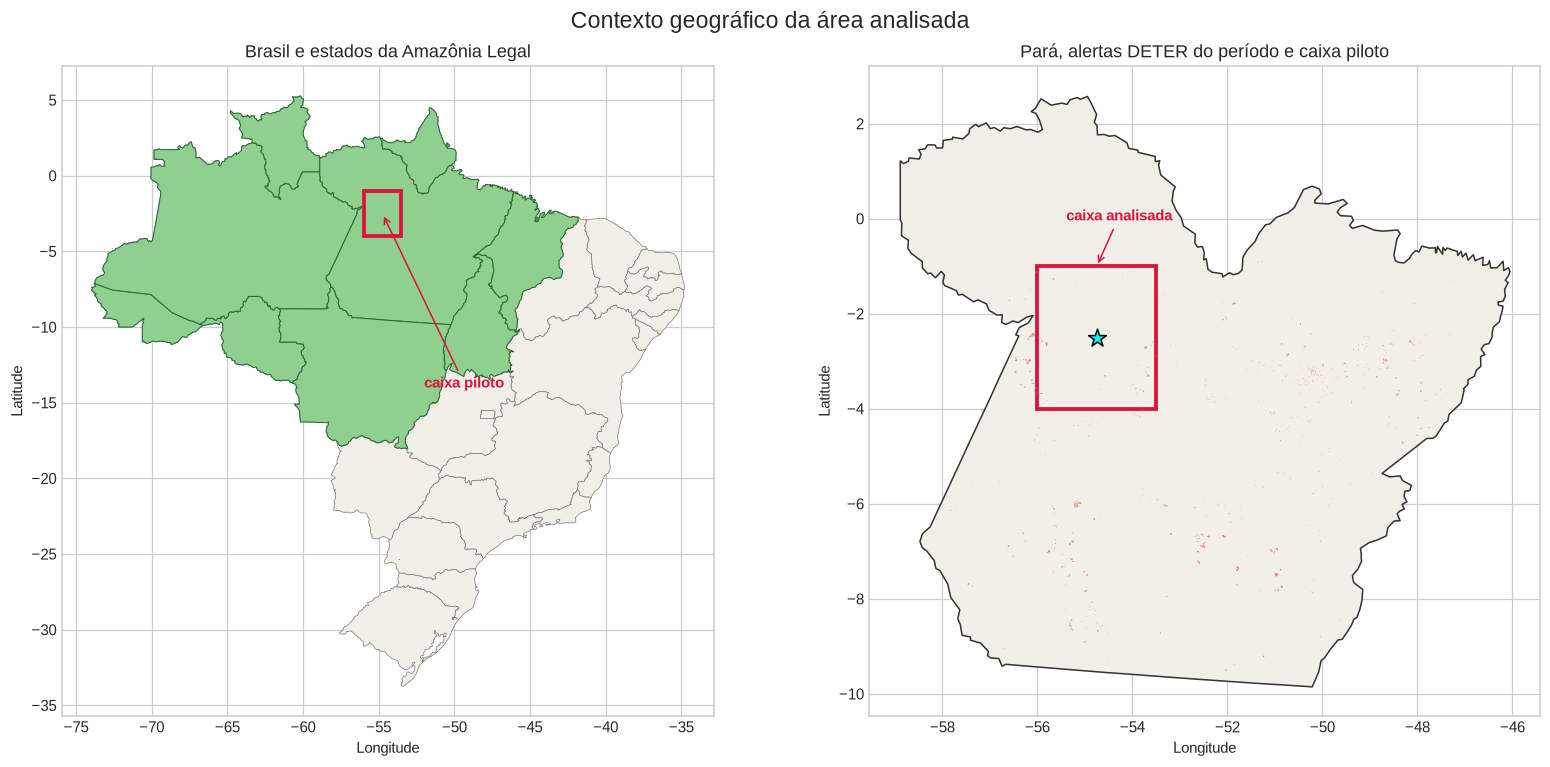

In [11]:
state_code_to_abbr = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA",
    "16": "AP", "17": "TO", "21": "MA", "51": "MT",
    "22": "PI", "23": "CE", "24": "RN", "25": "PB", "26": "PE",
    "27": "AL", "28": "SE", "29": "BA", "31": "MG", "32": "ES",
    "33": "RJ", "35": "SP", "41": "PR", "42": "SC", "43": "RS",
    "50": "MS", "52": "GO", "53": "DF",
}
amazon_legal_abbr = {"AC", "AP", "AM", "MA", "MT", "PA", "RO", "RR", "TO"}

ibge_states = gpd.read_file(ibge_path).to_crs("EPSG:4674")
ibge_states["sigla"] = ibge_states["codarea"].astype(str).map(state_code_to_abbr)
amazon_context = ibge_states[ibge_states["sigla"].isin(amazon_legal_abbr)]
para_context = ibge_states[ibge_states["sigla"] == "PA"]
deter_context = gpd.read_file(deter_path).to_crs("EPSG:4674")
deter_para = deter_context[deter_context["uf"] == "PA"]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

ibge_states.plot(ax=axes[0], color="#f2efe9", edgecolor="#777777", linewidth=.45)
amazon_context.plot(ax=axes[0], color="#8fcf8f", edgecolor="#2f6b3a", linewidth=.7)
axes[0].add_patch(
    Rectangle((west, south), east - west, north - south, fill=False, ec="crimson", lw=2.5)
)
axes[0].annotate(
    "caixa piloto",
    xy=((west + east) / 2, (south + north) / 2),
    xytext=(-52, -14),
    arrowprops={"arrowstyle": "->", "color": "crimson"},
    color="crimson",
    weight="bold",
)
axes[0].set(title="Brasil e estados da Amazônia Legal", xlabel="Longitude", ylabel="Latitude")
axes[0].set_aspect("equal")

para_context.plot(ax=axes[1], color="#f2efe9", edgecolor="#333333", linewidth=1)
deter_para.boundary.plot(ax=axes[1], color="#e76f51", linewidth=.35, alpha=.55)
axes[1].add_patch(
    Rectangle((west, south), east - west, north - south, fill=False, ec="crimson", lw=2.5)
)
axes[1].scatter(
    cfg["spatial"]["pilot_point"][1],
    cfg["spatial"]["pilot_point"][0],
    marker="*",
    s=150,
    color="cyan",
    edgecolor="black",
    zorder=5,
)
axes[1].annotate(
    "caixa analisada",
    xy=((west + east) / 2, north),
    xytext=(-20, 30),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "crimson"},
    color="crimson",
    weight="bold",
)
axes[1].set(
    title="Pará, alertas DETER do período e caixa piloto",
    xlabel="Longitude",
    ylabel="Latitude",
)
axes[1].set_aspect("equal")

fig.suptitle("Contexto geográfico da área analisada", fontsize=15)
fig.tight_layout()
plt.show()

## 4. Série horária em uma célula de grade

O ponto solicitado raramente coincide exatamente com o centro de uma célula. Usamos o vizinho mais próximo e registramos as coordenadas realmente escolhidas. A série continua em UTC; a conversão para horário local só deve ser feita se a pergunta científica exigir.

In [12]:
requested_lat, requested_lon = cfg["spatial"]["pilot_point"]
point = extract_nearest_point(climate, requested_lat, requested_lon).sortby(time_name)
used_lat = float(point[lat_name])
used_lon = float(point[lon_name])

point_df = point.to_dataframe().reset_index()
point_df[time_name] = pd.to_datetime(point_df[time_name])
point_df["hora_utc"] = point_df[time_name].dt.hour

display(
    pd.DataFrame(
        {
            "coordenada": ["latitude", "longitude"],
            "solicitada": [requested_lat, requested_lon],
            "usada": [used_lat, used_lon],
            "diferença_em_graus": [used_lat - requested_lat, used_lon - requested_lon],
        }
    )
)
print(f"A série possui {point.sizes[time_name]} timestamps horários em UTC.")

  coordenada  solicitada  usada  diferença_em_graus
0   latitude       -2.50  -2.50                 0.0
1  longitude      -54.75 -54.75                 0.0
A série possui 192 timestamps horários em UTC.


### Controle de qualidade mínimo

Antes de interpretar curvas, verificamos lacunas, duplicatas, ordem temporal, passo de amostragem e amplitude. Uma série aparentemente suave ainda pode estar irregular ou incompleta.

In [13]:
qc = qc_table(point, time_name).rename(
    columns={
        "variable": "variável", "n": "válidos", "n_nan": "ausentes",
        "missing_fraction": "fração_ausente", "mean": "média",
        "std": "desvio_padrão", "n_unique": "valores_únicos",
    }
)
regularity = time_regularity(point, time_name, expected="1h")

display(qc.round({"fração_ausente": 3, "min": 3, "média": 3, "max": 3, "desvio_padrão": 3}))
display(pd.DataFrame([regularity]).rename(columns={
    "n_timestamps": "timestamps", "monotonic_increasing": "ordem_crescente",
    "duplicates": "duplicatas", "unexpected_steps": "passos_inesperados",
    "modal_step": "passo_modal",
}))

                variável  válidos  ausentes  fração_ausente       min  \
0                  t2m_c      192         0             0.0    25.721   
1                  d2m_c      192         0             0.0    19.792   
2                vpd_kpa      192         0             0.0     0.488   
3   surface_pressure_hpa      192         0             0.0  1001.175   
4  precip_mm_hour_ending      192         0             0.0     0.000   
5         wind_speed_10m      192         0             0.0     2.234   

      média       max  desvio_padrão  valores_únicos  
0    29.140    34.028          2.305             192  
1    22.592    24.320          1.084             191  
2     1.324     2.980          0.694             192  
3  1005.040  1008.448          1.632             191  
4     0.001     0.080          0.008              16  
5     3.239     4.784          0.560             192  
   timestamps  ordem_crescente  duplicatas  passos_inesperados     passo_modal
0         192           

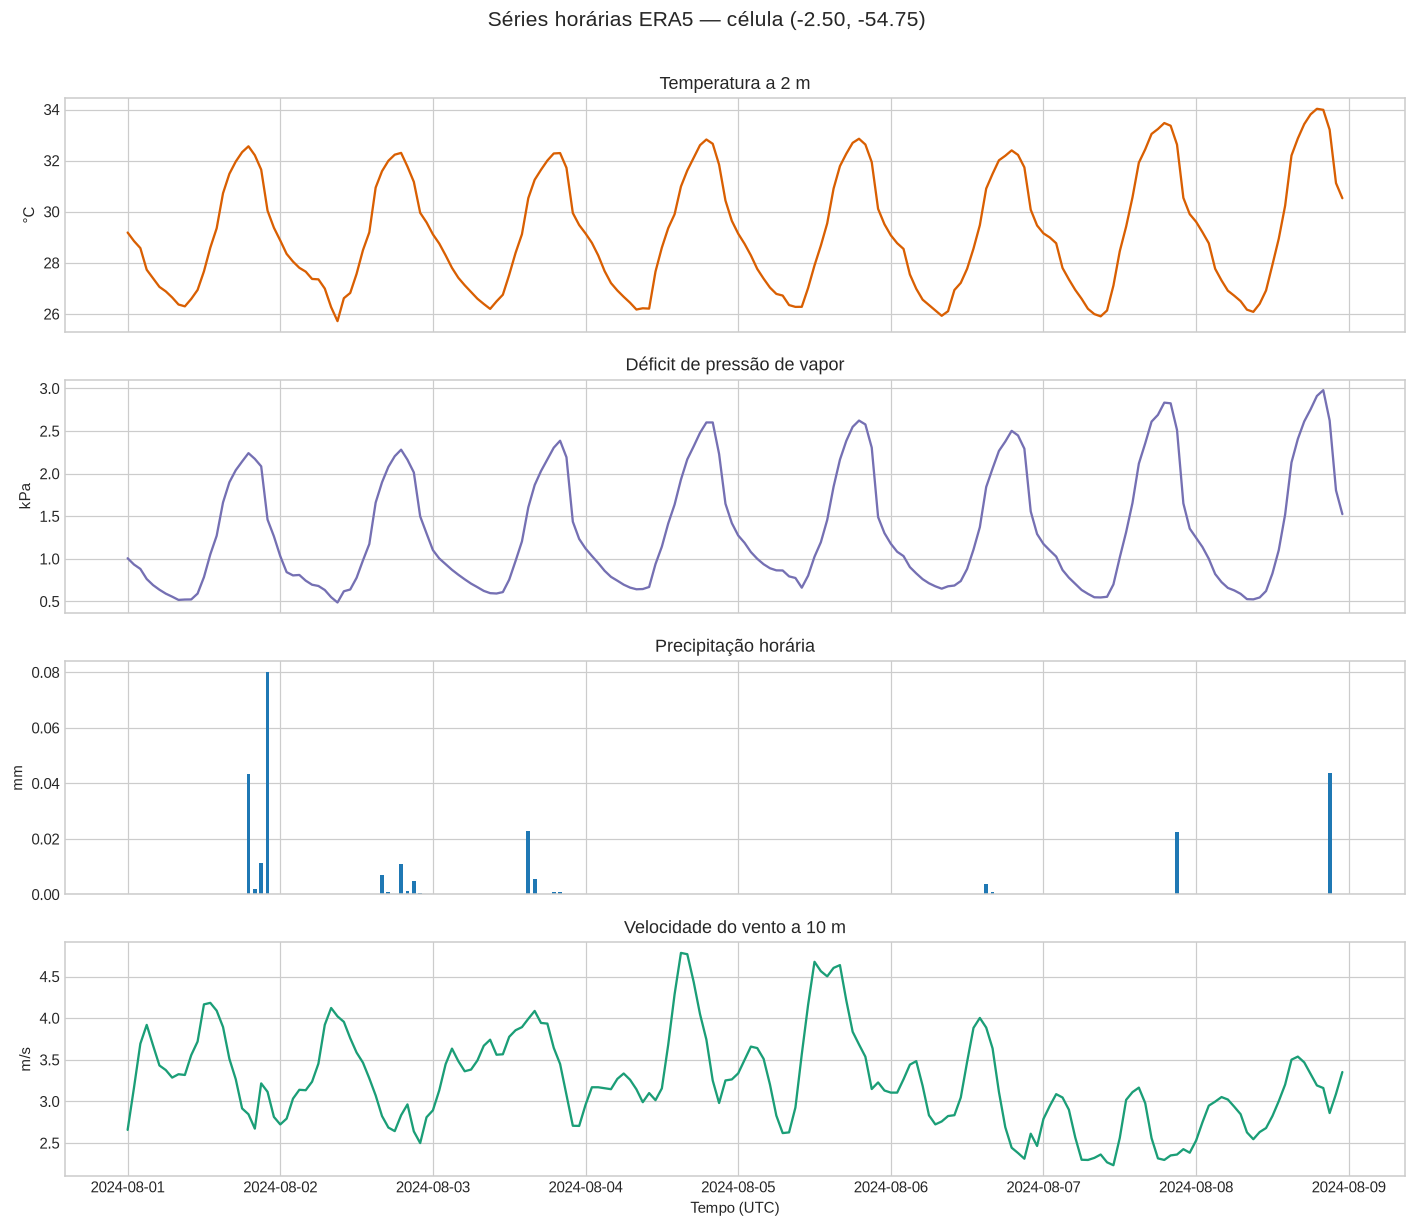

In [14]:
series_specs = [
    ("t2m_c", "Temperatura a 2 m", "°C", "#d95f02"),
    ("vpd_kpa", "Déficit de pressão de vapor", "kPa", "#7570b3"),
    ("precip_mm_hour_ending", "Precipitação horária", "mm", "#1f78b4"),
    ("wind_speed_10m", "Velocidade do vento a 10 m", "m/s", "#1b9e77"),
]
fig, axes = plt.subplots(len(series_specs), 1, figsize=(13, 11), sharex=True)
for ax, (variable, title, unit, color) in zip(axes, series_specs):
    if variable == "precip_mm_hour_ending":
        ax.bar(point_df[time_name], point_df[variable], width=0.025, color=color)
    else:
        ax.plot(point_df[time_name], point_df[variable], lw=1.5, color=color)
    ax.set(title=title, ylabel=unit)
axes[-1].set_xlabel("Tempo (UTC)")
fig.suptitle(f"Séries horárias ERA5 — célula ({used_lat:.2f}, {used_lon:.2f})", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

## 5. Da hora ao dia: agregações com semânticas diferentes

Temperatura, VPD, pressão e vento são resumidos pela **média diária**. Precipitação é um acumulado e deve ser **somada**. Além disso, a coordenada da precipitação é deslocada uma hora para trás antes do `resample`, pois cada valor representa a hora que termina no timestamp.

Misturar média e soma ou ignorar a semântica temporal produziria uma série diária fisicamente incorreta.

In [15]:
science_start = str(cfg["time"]["science_start"])
science_end = str(cfg["time"]["science_end"])
daily = aggregate_daily(point, science_start, science_end)
daily_df = daily.to_dataframe().reset_index()
daily_df[time_name] = pd.to_datetime(daily_df[time_name])

display(daily_df.round(3))
print("Dias científicos:", len(daily_df))
print("O oitavo dia baixado é apoio ao cálculo; ele não aparece na tabela científica final.")

  valid_time  number  latitude  longitude      t2m_c      d2m_c  vpd_kpa  \
0 2024-08-01       0      -2.5     -54.75  29.021000  23.261000    1.179   
1 2024-08-02       0      -2.5     -54.75  28.945999  23.079000    1.191   
2 2024-08-03       0      -2.5     -54.75  28.917000  22.827999    1.227   
3 2024-08-04       0      -2.5     -54.75  29.167000  22.218000    1.390   
4 2024-08-05       0      -2.5     -54.75  29.108999  21.962999    1.419   
5 2024-08-06       0      -2.5     -54.75  28.936001  22.243000    1.331   
6 2024-08-07       0      -2.5     -54.75  29.415001  22.420000    1.424   

   surface_pressure_hpa  wind_speed_10m  precip_mm_day  
0           1006.471985           3.409          0.137  
1           1005.942017           3.192          0.026  
2           1005.213989           3.518          0.031  
3           1005.119995           3.474          0.000  
4           1005.526978           3.640          0.000  
5           1004.895020           3.063          

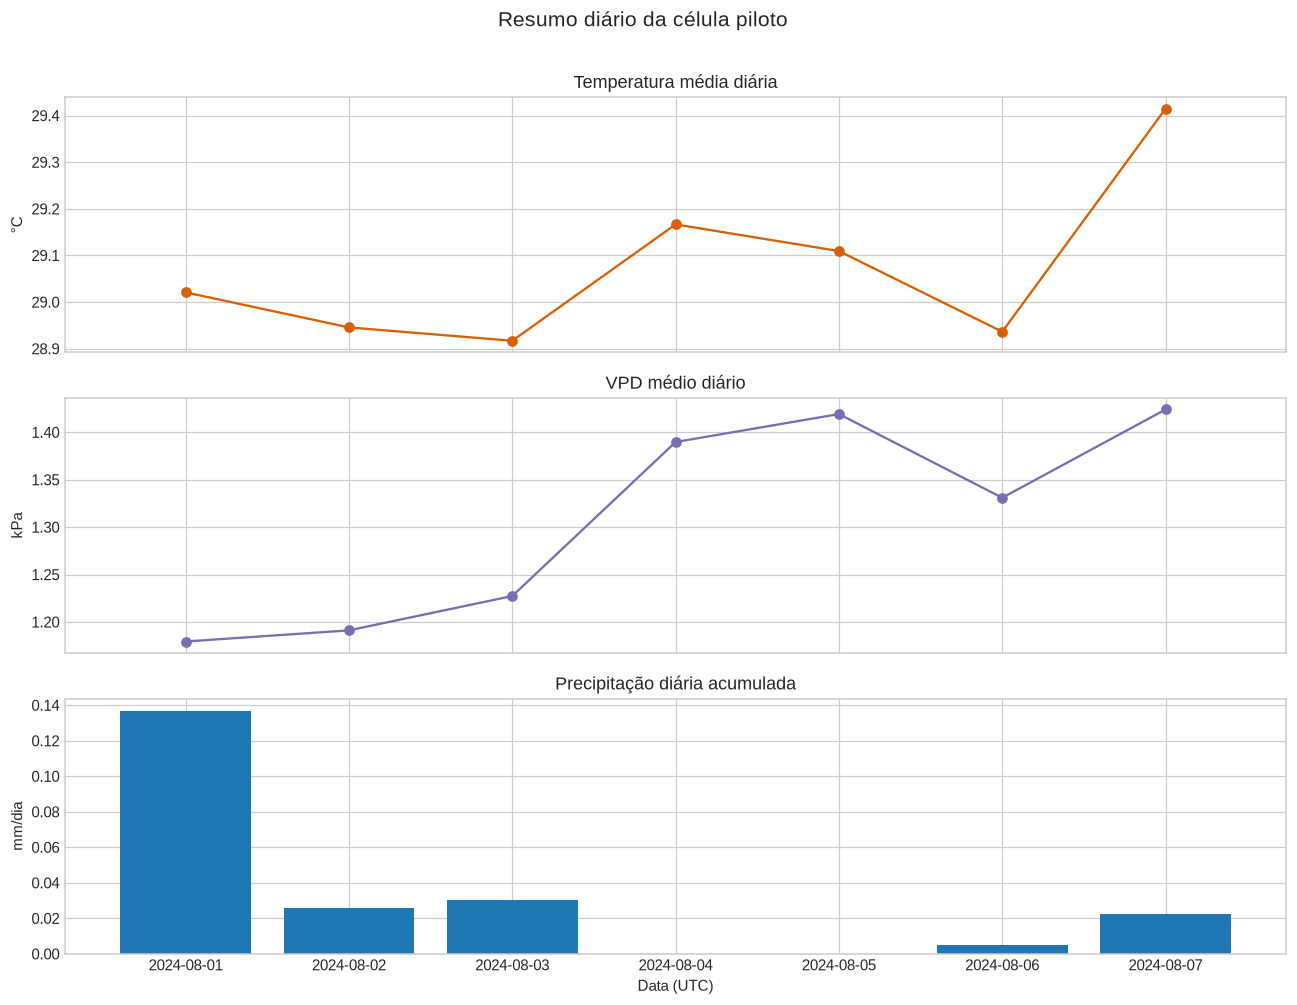

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(daily_df[time_name], daily_df["t2m_c"], marker="o", color="#d95f02")
axes[0].set(title="Temperatura média diária", ylabel="°C")
axes[1].plot(daily_df[time_name], daily_df["vpd_kpa"], marker="o", color="#7570b3")
axes[1].set(title="VPD médio diário", ylabel="kPa")
axes[2].bar(daily_df[time_name], daily_df["precip_mm_day"], color="#1f78b4")
axes[2].set(title="Precipitação diária acumulada", ylabel="mm/dia", xlabel="Data (UTC)")
fig.suptitle("Resumo diário da célula piloto", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

### Ciclo diurno e relações entre variáveis

Agrupar todas as observações pela hora UTC revela o ciclo médio dentro desta pequena janela. As faixas mostram mínimo e máximo observados; com apenas oito dias, elas descrevem o piloto, não uma climatologia.

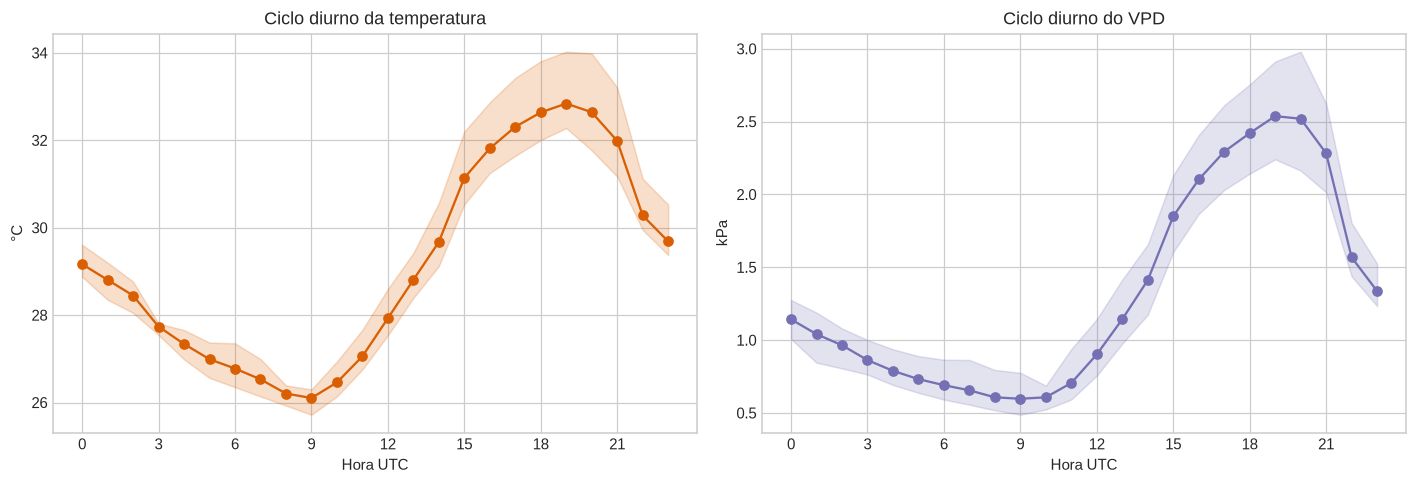

In [17]:
diurnal = point_df.groupby("hora_utc").agg(
    temp_media=("t2m_c", "mean"), temp_min=("t2m_c", "min"), temp_max=("t2m_c", "max"),
    vpd_medio=("vpd_kpa", "mean"), vpd_min=("vpd_kpa", "min"), vpd_max=("vpd_kpa", "max"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].fill_between(diurnal["hora_utc"], diurnal["temp_min"], diurnal["temp_max"], alpha=.2, color="#d95f02")
axes[0].plot(diurnal["hora_utc"], diurnal["temp_media"], marker="o", color="#d95f02")
axes[0].set(title="Ciclo diurno da temperatura", xlabel="Hora UTC", ylabel="°C", xticks=range(0, 24, 3))
axes[1].fill_between(diurnal["hora_utc"], diurnal["vpd_min"], diurnal["vpd_max"], alpha=.2, color="#7570b3")
axes[1].plot(diurnal["hora_utc"], diurnal["vpd_medio"], marker="o", color="#7570b3")
axes[1].set(title="Ciclo diurno do VPD", xlabel="Hora UTC", ylabel="kPa", xticks=range(0, 24, 3))
fig.tight_layout()
plt.show()

                       t2m_c  vpd_kpa  wind_speed_10m  precip_mm_hour_ending
t2m_c                   1.00     0.98            0.03                   0.19
vpd_kpa                 0.98     1.00            0.02                   0.18
wind_speed_10m          0.03     0.02            1.00                  -0.06
precip_mm_hour_ending   0.19     0.18           -0.06                   1.00
Cuidado: VPD é derivado de temperatura e ponto de orvalho; correlação não significa independência nem causalidade.


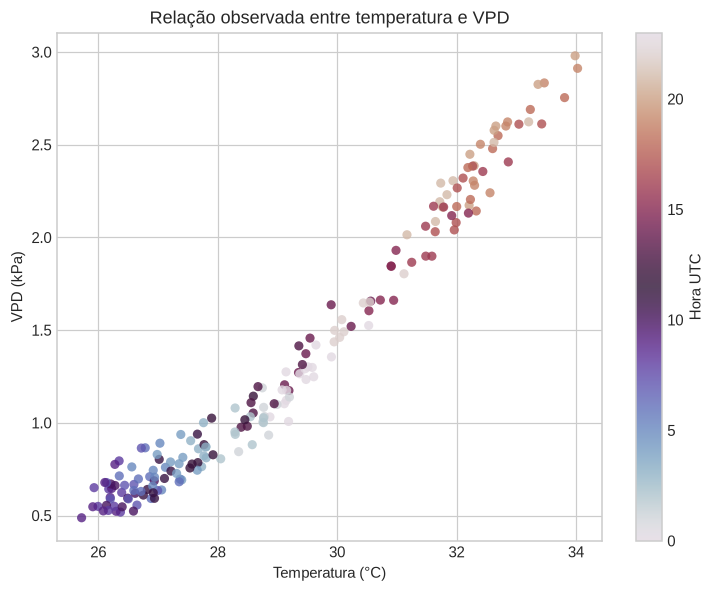

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(point_df["t2m_c"], point_df["vpd_kpa"], c=point_df["hora_utc"],
                     cmap="twilight", alpha=.8, edgecolor="none")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Hora UTC")
ax.set(title="Relação observada entre temperatura e VPD", xlabel="Temperatura (°C)", ylabel="VPD (kPa)")
plt.show()

correlation = point_df[["t2m_c", "vpd_kpa", "wind_speed_10m", "precip_mm_hour_ending"]].corr()
display(correlation.round(2))
print("Cuidado: VPD é derivado de temperatura e ponto de orvalho; correlação não significa independência nem causalidade.")

## 6. DETER: alertas como polígonos no espaço e eventos no tempo

O arquivo baixado contém alertas de toda a Amazônia Legal no período solicitado. Primeiro recortamos cada geometria pela caixa piloto; depois calculamos a área da parte efetivamente dentro da caixa em uma projeção equivalente (`EPSG:6933`).

- **Contagem** responde quantos polígonos foram detectados.
- **Área** responde quanto território os polígonos cobrem após o recorte.

Essas medidas não são intercambiáveis. DETER apoia fiscalização e indica perturbação recente; não substitui a taxa anual consolidada do PRODES.

In [19]:
deter_raw = deter_context.copy()
deter_clip = clip_bbox(deter_raw, area)
deter_clip = add_area_km2(deter_clip, cfg["spatial"]["equal_area_crs"])

date_candidates = [c for c in cfg["terrabrasilis"]["date_field_candidates"] if c in deter_clip.columns]
if not date_candidates:
    raise KeyError("Nenhum campo de data esperado foi encontrado no DETER.")
deter_date = date_candidates[0]
deter_clip[deter_date] = pd.to_datetime(deter_clip[deter_date])

deter_summary = summarize_deter(deter_clip, equal_area_crs=cfg["spatial"]["equal_area_crs"])
display(pd.DataFrame({
    "etapa": ["arquivo DETER no período", "após recorte pela caixa"],
    "n_polígonos": [len(deter_raw), len(deter_clip)],
}))
display(deter_summary.round({"area_km2": 3}))
print(f"Área total recortada: {deter_clip['area_km2'].sum():.3f} km²")

                      etapa  n_polígonos
0  arquivo DETER no período         1635
1   após recorte pela caixa           65
              classname  n_alerts  area_km2
2         CS_GEOMETRICO         7    37.419
3            DEGRADACAO        14    15.490
1        CS_DESORDENADO        11     8.666
0  CICATRIZ_DE_QUEIMADA        11     3.412
4       DESMATAMENTO_CR        22     2.725
Área total recortada: 67.712 km²


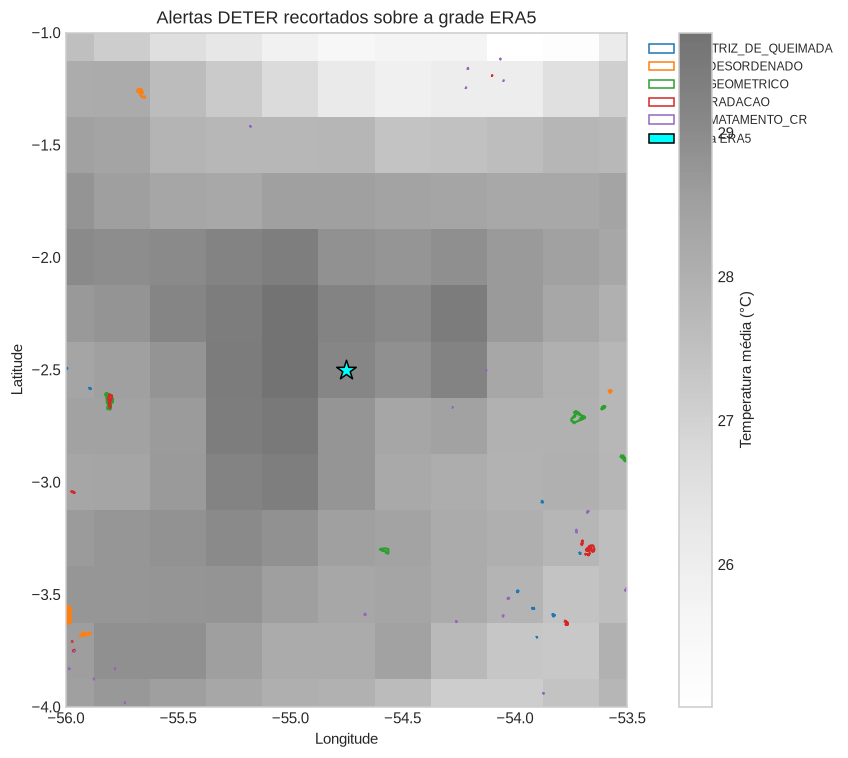

In [20]:
class_names = sorted(deter_clip["classname"].dropna().unique())
palette = plt.get_cmap("tab10")
class_colors = {name: palette(i % 10) for i, name in enumerate(class_names)}

fig, ax = plt.subplots(figsize=(10, 7))
climate["t2m_c"].mean(time_name).plot(
    ax=ax, cmap="Greys", alpha=.55, cbar_kwargs={"label": "Temperatura média (°C)"}
)
for class_name, group in deter_clip.groupby("classname"):
    group.boundary.plot(ax=ax, color=class_colors[class_name], linewidth=1.4)
ax.scatter(used_lon, used_lat, marker="*", s=180, color="cyan", edgecolor="black")
handles = [Patch(facecolor="none", edgecolor=class_colors[name], label=name) for name in class_names]
handles.append(Patch(facecolor="cyan", edgecolor="black", label="célula ERA5"))
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
ax.set(xlim=(west, east), ylim=(south, north), title="Alertas DETER recortados sobre a grade ERA5",
       xlabel="Longitude", ylabel="Latitude")
fig.tight_layout()
plt.show()

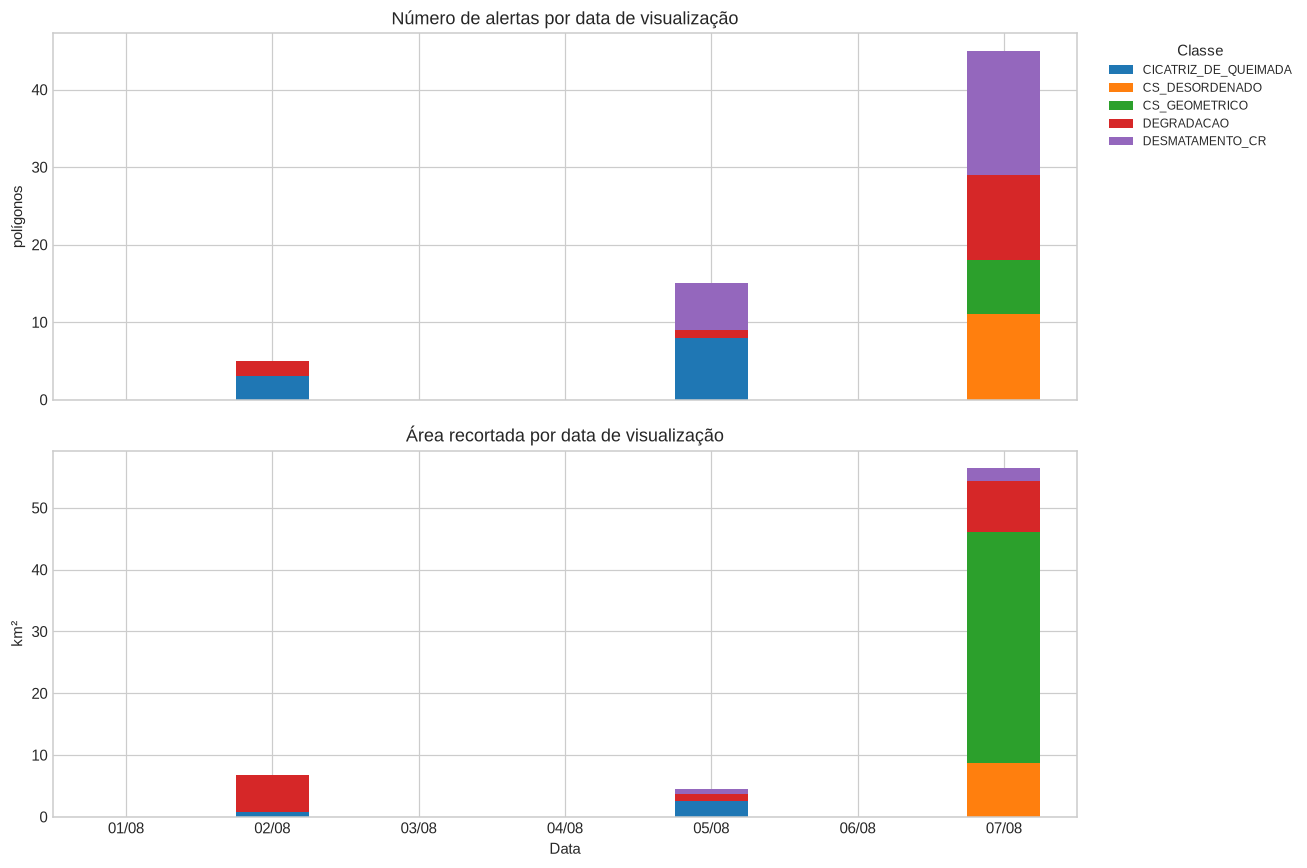

In [21]:
full_dates = pd.date_range(science_start, science_end, freq="D")
deter_by_day_class = (
    deter_clip.groupby([deter_date, "classname"], observed=True)
    .agg(alertas=("id", "size"), area_km2=("area_km2", "sum"))
    .reset_index()
)
count_pivot = deter_by_day_class.pivot(index=deter_date, columns="classname", values="alertas").reindex(full_dates, fill_value=0).fillna(0)
area_pivot = deter_by_day_class.pivot(index=deter_date, columns="classname", values="area_km2").reindex(full_dates, fill_value=0).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
count_pivot.plot.bar(stacked=True, ax=axes[0], color=[class_colors[c] for c in count_pivot.columns])
axes[0].set(title="Número de alertas por data de visualização", ylabel="polígonos", xlabel="")
area_pivot.plot.bar(stacked=True, ax=axes[1], color=[class_colors[c] for c in area_pivot.columns])
axes[1].set(title="Área recortada por data de visualização", ylabel="km²", xlabel="Data")
axes[0].legend(title="Classe", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1].legend().remove()
axes[1].set_xticklabels([d.strftime("%d/%m") for d in full_dates], rotation=0)
fig.tight_layout()
plt.show()

## 7. Linha do tempo conjunta: comparação descritiva, não causal

Alinhamos os resumos diários apenas para enxergar se os registros ocupam os mesmos dias. A “data de visualização” do alerta não é necessariamente o instante exato em que a perturbação ocorreu, e sete dias são insuficientes para inferir relações entre clima e cobertura vegetal.

  valid_time      t2m_c  vpd_kpa  precip_mm_day  deter_alertas  deter_area_km2
0 2024-08-01  29.021000    1.179          0.137            0.0           0.000
1 2024-08-02  28.945999    1.191          0.026            5.0           6.822
2 2024-08-03  28.917000    1.227          0.031            0.0           0.000
3 2024-08-04  29.167000    1.390          0.000            0.0           0.000
4 2024-08-05  29.108999    1.419          0.000           15.0           4.449
5 2024-08-06  28.936001    1.331          0.005            0.0           0.000
6 2024-08-07  29.415001    1.424          0.022           45.0          56.442


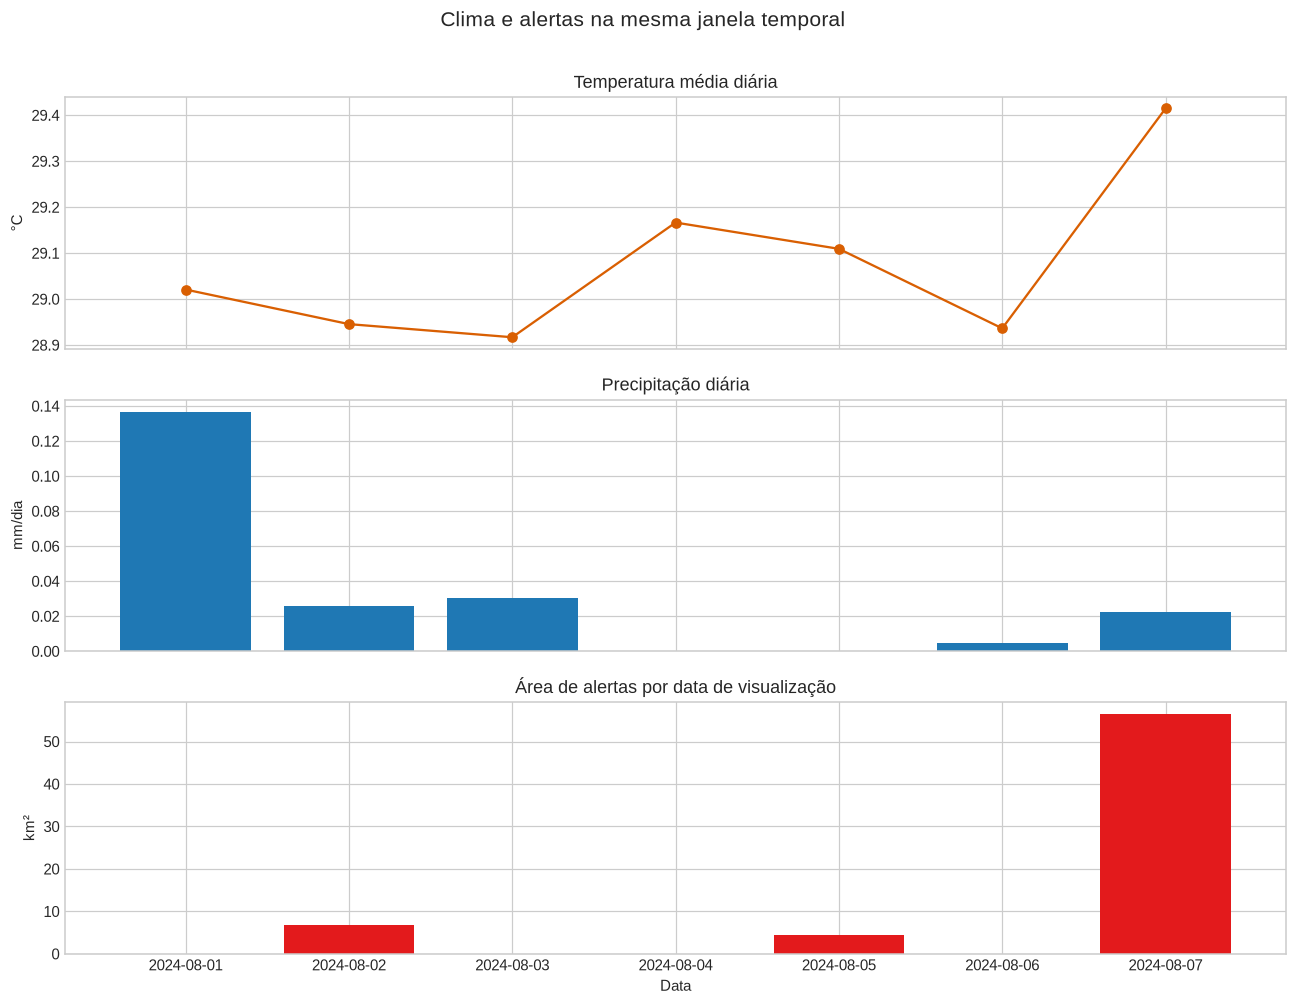

In [22]:
deter_daily = pd.DataFrame({
    time_name: full_dates,
    "deter_alertas": count_pivot.sum(axis=1).to_numpy(),
    "deter_area_km2": area_pivot.sum(axis=1).to_numpy(),
})
combined = daily_df.merge(deter_daily, on=time_name, how="left")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(combined[time_name], combined["t2m_c"], marker="o", color="#d95f02", label="temperatura")
axes[0].set(ylabel="°C", title="Temperatura média diária")
axes[1].bar(combined[time_name], combined["precip_mm_day"], color="#1f78b4", label="precipitação")
axes[1].set(ylabel="mm/dia", title="Precipitação diária")
axes[2].bar(combined[time_name], combined["deter_area_km2"], color="#e31a1c", label="área DETER")
axes[2].set(ylabel="km²", title="Área de alertas por data de visualização", xlabel="Data")
fig.suptitle("Clima e alertas na mesma janela temporal", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

display(combined[[time_name, "t2m_c", "vpd_kpa", "precip_mm_day", "deter_alertas", "deter_area_km2"]].round(3))

## 8. Exportação opcional dos derivados

Dados brutos permanecem imutáveis. Quando habilitada, esta etapa escreve novos produtos processados: a série diária em NetCDF e os alertas já recortados em Parquet. A configuração e o inventário acima documentam como eles foram obtidos.

In [23]:
daily_output = processed_dir / "era5_piloto_point_daily_didatico.nc"
deter_output = processed_dir / "deter_piloto_bbox_didatico.parquet"

if SALVAR_DERIVADOS:
    processed_dir.mkdir(parents=True, exist_ok=True)
    daily.to_netcdf(daily_output)
    deter_clip.to_parquet(deter_output)
    print("Salvo:", daily_output.relative_to(ROOT))
    print("Salvo:", deter_output.relative_to(ROOT))
else:
    print("Exportação desativada. Produtos que seriam escritos:")
    print(" -", daily_output.relative_to(ROOT))
    print(" -", deter_output.relative_to(ROOT))

Exportação desativada. Produtos que seriam escritos:
 - data/processed/era5_piloto_point_daily_didatico.nc
 - data/processed/deter_piloto_bbox_didatico.parquet


In [24]:
status_qc = (
    regularity["unexpected_steps"] == 0
    and regularity["duplicates"] == 0
    and qc["fração_ausente"].max() == 0
)
qc_label = "aprovadas" if status_qc else "requerem inspeção"
top_class = deter_summary.iloc[0].classname
top_area = deter_summary.iloc[0].area_km2
summary_lines = [
    "## Síntese automática deste piloto",
    "",
    f"- O ERA5 forneceu **{point.sizes[time_name]} registros horários** na célula ({used_lat:.2f}, {used_lon:.2f}).",
    f"- Regularidade e completude mínimas: **{qc_label}**.",
    f"- A janela científica gerou **{len(daily_df)} valores diários**.",
    f"- O recorte espacial contém **{len(deter_clip)} polígonos DETER**, totalizando **{deter_clip.area_km2.sum():.2f} km²** após clipping.",
    f"- O maior grupo por área foi **{top_class}** ({top_area:.2f} km²).",
    "",
    "Esses números descrevem o arquivo e a janela piloto; não constituem, por si sós, evidência de causalidade, caos ou ponto de não retorno.",
]
display(Markdown(chr(10).join(summary_lines)))

<IPython.core.display.Markdown object>


## Como apresentar estes resultados ao orientador

Uma sequência curta e clara é:

1. **Inventário:** quais arquivos, fontes, período e caixa espacial foram usados.
2. **Mapa ERA5:** a variável é uma grade, e o ponto analisado é uma célula da reanálise.
3. **Séries horárias:** há ciclo diurno, chuva intermitente e variáveis com unidades diferentes.
4. **Controle de qualidade:** a grade temporal precisa ser regular e sem lacunas antes da análise dinâmica.
5. **Agregação diária:** médias e somas seguem semânticas físicas diferentes.
6. **Mapa DETER:** alertas são polígonos; área após recorte é mais informativa que apenas contagem.
7. **Linha do tempo conjunta:** serve para formular perguntas, não para responder causalidade com sete dias.

## Limites atuais e próximo passo científico

Este piloto valida o encanamento de dados, mas é curto demais para reconstrução robusta do espaço de fases, estimativa de Lyapunov, sazonalidade anual ou comparação entre regimes. O próximo conjunto deve:

- cobrir vários anos e ser baixado em blocos mensais ou anuais controlados;
- comparar múltiplas células/regiões predefinidas;
- incorporar PRODES/MapBiomas para perturbação histórica, mantendo DETER como alerta recente;
- registrar lacunas, tendência, sazonalidade e mudanças de qualidade;
- construir séries brutas e anomalias com proveniência explícita;
- somente então conectar estas séries ao `Laboratorio_Sistemas_Dinamicos_Floresta_Atmosfera.ipynb`.

> A ponte correta entre os cadernos é: **aquisição → qualidade → harmonização → séries → hipóteses nulas → ferramentas não lineares → interpretação cautelosa**.